# Canadian High Resolution Deterministic Prediction System (HRDPS)

In this example, we will complete the following:

1) Download the first 12 hours of HRDPS Data for 0 to 10cm soil temperature. 
2) We will create a set of graphics of the 0 to 10cm soil temperature for the next 12 hours across British Columbia and Alberta.

[***WxData HRDPS Client Documentation***](https://edrewitz.github.io/WxData/hrdps)

## Imports

In [1]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import metpy.plots as mpplots
import pandas as pd

from wxdata import hrdps
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patheffects import withStroke 
from datetime import timedelta

# IPython magic command used in Jupyter Notebooks to display plots directly below the code cell that generates them
%matplotlib inline

### WxData RDPS Client

```python
def hrdps(final_forecast_hour=48, 
             step=1,
             path=f"HRDPS",
             proxies=None, 
             clear_recycle_bin=False,
             process_data=True,
             convert_temperature=True,
             convert_to='celsius',
             chunk_size=8192,
             notifications='off',
             level_type='pressure',
             clear_data=False,
            variable='geopotential height',
            level=500,
            layer=[1000, 500]):
```

In this example, we will need to change certain optional arguments to the following settings:

1) `final_forecast_hour=12`
2) `level_type='depth below surface'`
4) `layer=[0, 10]`
5) `variable='soil temperature'`

In [2]:
soil_temperature = hrdps(final_forecast_hour=12,
                   level_type='depth below surface',
                   layer=[0, 10],
                   variable='soil temperature')

Scanning https://dd.weather.gc.ca/ HRDPS SOIL TEMPERATURE 0to10cm
Please Wait...
Server Scan Complete!


20260820T18Z_MSC_HRDPS_TSOIL_DBS-0-10cm_RLatLon0.0225_PT000H.grib2:   0%|          | 0.00/3.67M [00:00<?, ?B/s…

20260820T18Z_MSC_HRDPS_TSOIL_DBS-0-10cm_RLatLon0.0225_PT001H.grib2:   0%|          | 0.00/2.56M [00:00<?, ?B/s…

20260820T18Z_MSC_HRDPS_TSOIL_DBS-0-10cm_RLatLon0.0225_PT002H.grib2:   0%|          | 0.00/2.55M [00:00<?, ?B/s…

20260820T18Z_MSC_HRDPS_TSOIL_DBS-0-10cm_RLatLon0.0225_PT003H.grib2:   0%|          | 0.00/2.54M [00:00<?, ?B/s…

...

20260820T18Z_MSC_HRDPS_TSOIL_DBS-0-10cm_RLatLon0.0225_PT009H.grib2:   0%|          | 0.00/2.47M [00:00<?, ?B/s…

20260820T18Z_MSC_HRDPS_TSOIL_DBS-0-10cm_RLatLon0.0225_PT010H.grib2:   0%|          | 0.00/2.46M [00:00<?, ?B/s…

20260820T18Z_MSC_HRDPS_TSOIL_DBS-0-10cm_RLatLon0.0225_PT011H.grib2:   0%|          | 0.00/2.46M [00:00<?, ?B/s…

20260820T18Z_MSC_HRDPS_TSOIL_DBS-0-10cm_RLatLon0.0225_PT012H.grib2:   0%|          | 0.00/2.45M [00:00<?, ?B/s…

HRDPS SOIL TEMPERATURE 0to10cm Download Complete!

Data Processing...
HRDPS Data Processing Complete: SOIL TEMPERATURE - 0to10cm


## Inspecting Our Data

In [3]:
soil_temperature

<xarray.Dataset> Size: 223MB
Dimensions:              (step: 13, y: 1290, x: 2540)
Coordinates:
  * step                 (step) float64 104B 0.0 1.0 2.0 3.0 ... 10.0 11.0 12.0
    latitude             (y, x) float64 26MB dask.array<chunksize=(1290, 2540), meta=np.ndarray>
    longitude            (y, x) float64 26MB dask.array<chunksize=(1290, 2540), meta=np.ndarray>
    time                 datetime64[ns] 8B ...
    depthBelowLandLayer  float64 8B ...
    valid_time           datetime64[ns] 8B ...
Dimensions without coordinates: y, x
Data variables:
    soil_temperature     (step, y, x) float32 170MB dask.array<chunksize=(1, 1290, 2540), meta=np.ndarray>
Attributes:
    GRIB_edition:            2
    GRIB_centre:             cwao
    GRIB_centreDescription:  Canadian Meteorological Service - Montreal
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             Canadian Meteorological Service - Montreal
    history:                 2026-08-20T17:53 GRIB to CDM+CF via cfgrib-0.9.1...

## Creating Our Plot

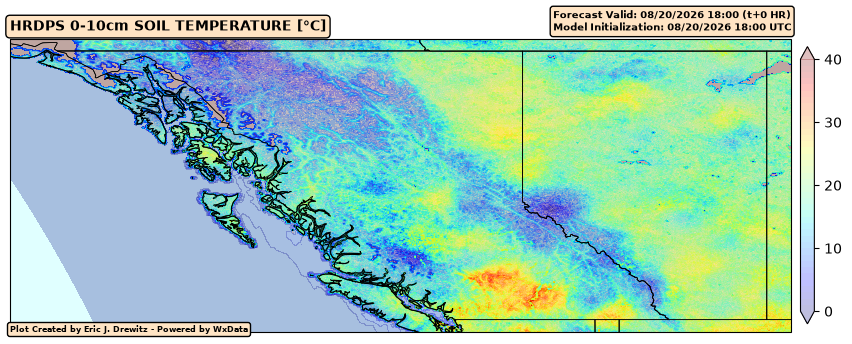

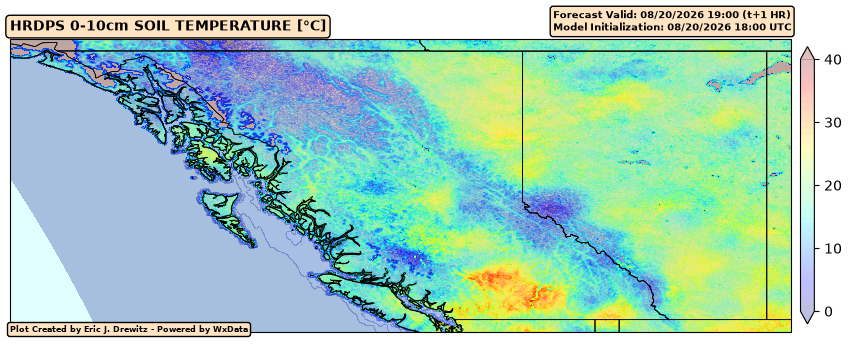

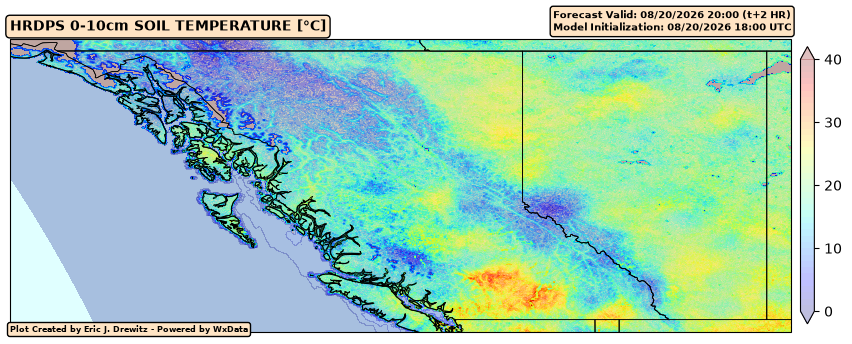

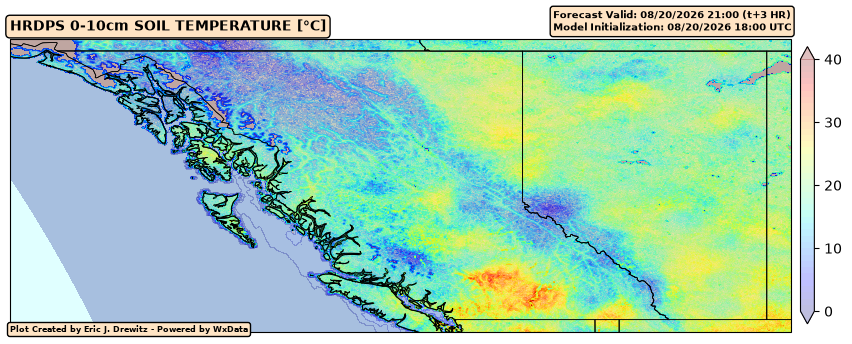

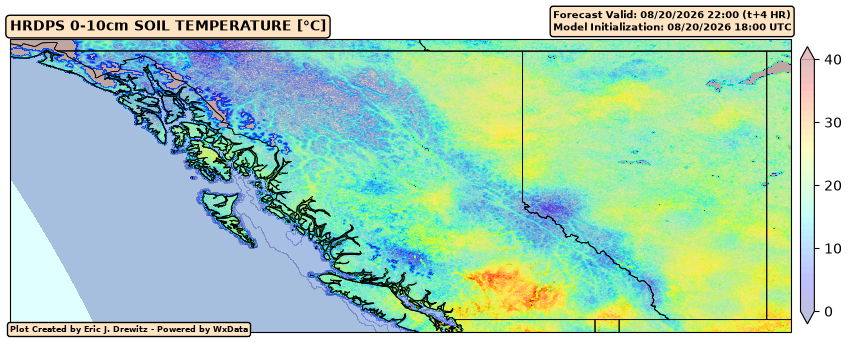

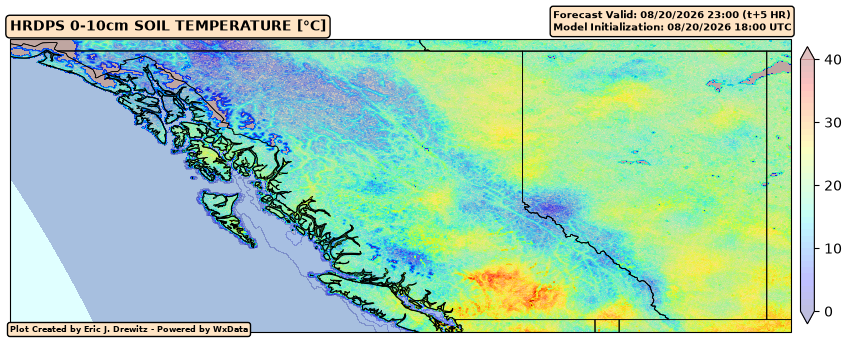

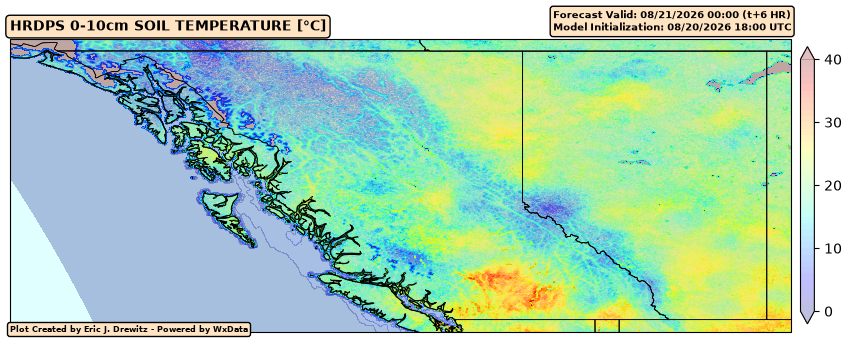

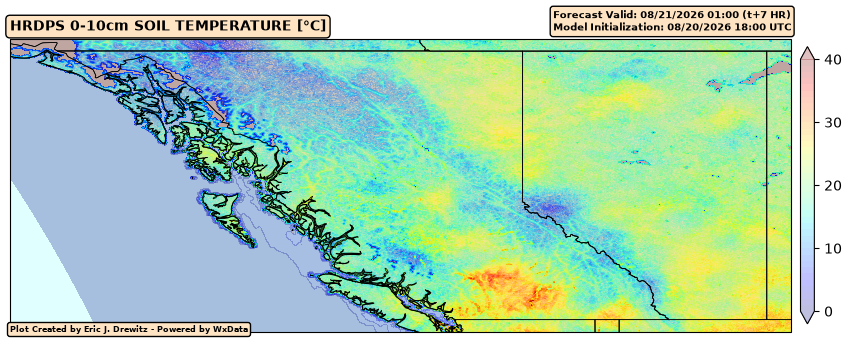

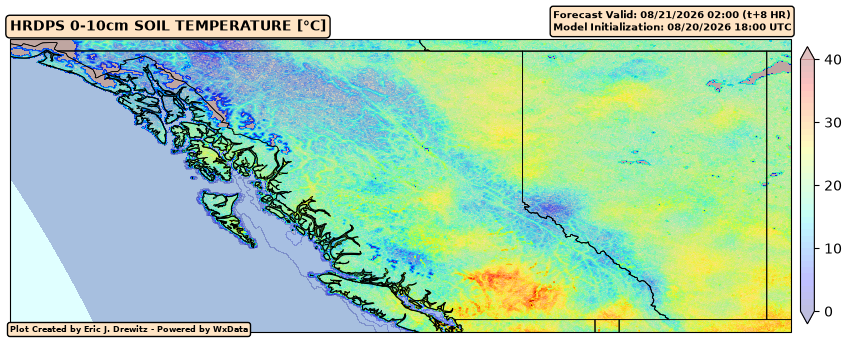

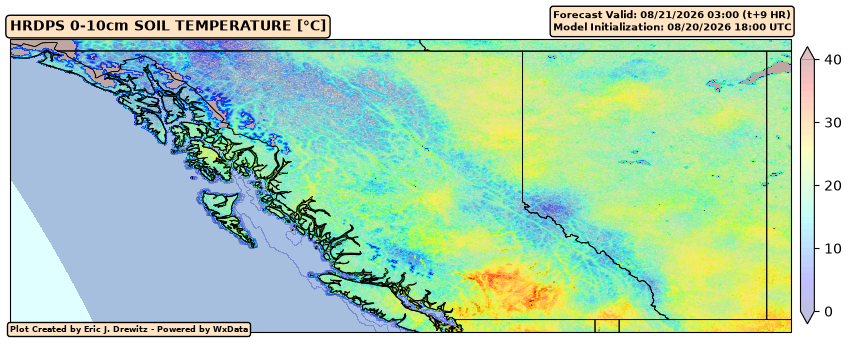

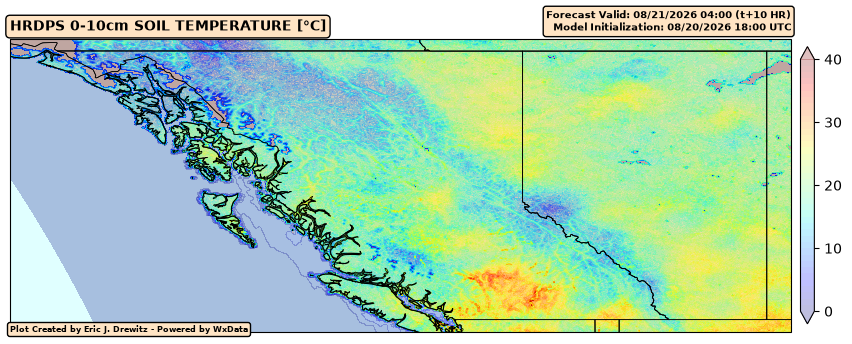

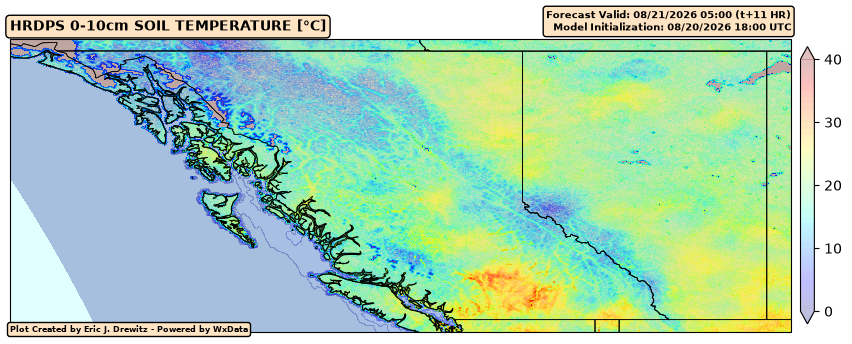

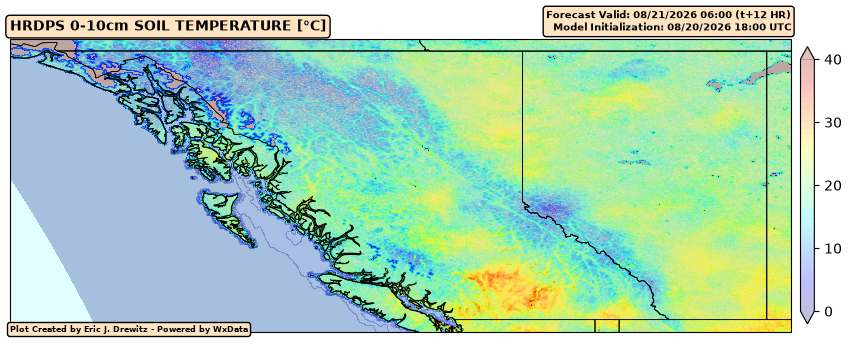

In [4]:
# Create our figure
for i in range(0, len(soil_temperature['step']), 1):
    fig = plt.figure(figsize=(12,12))
    
    # Create our subplot with a PlateCarree (lat/lon) projection
    ax = fig.add_subplot(1,1,1, projection=ccrs.PlateCarree())
    
    # Set our boundaries in a latlon format of [western_bound, eastern_bound, southern_bound, northern_bound] followed by our PlateCarree projection
    ax.set_extent([-141, -109, 48.5, 60.5], ccrs.PlateCarree())
    
    # Add our features to the map 
    # Add our coastlines
    ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.75, zorder=3)
    
    # Add the oceans, land, states, lakes and Canadian provinces and color them light cyan
    ax.add_feature(cfeature.OCEAN, color='lightcyan', zorder=1)
    ax.add_feature(cfeature.LAKES, color='lightcyan', zorder=1)
    ax.add_feature(cfeature.LAND, color='navajowhite', zorder=1)
    ax.add_feature(cfeature.STATES, edgecolor='black', linewidth=0.5, zorder=5)
    province_boundaries = cfeature.NaturalEarthFeature(
        category="cultural",
        name="admin_1_states_provinces_lines",
        scale="50m",
        facecolor="none",
        edgecolor="black",
    )
    ax.add_feature(province_boundaries, linewidth=0.5, zorder=5)
    
    # Add our filled contours for temperature
    cs = ax.contourf(soil_temperature['longitude'], 
                   soil_temperature['latitude'], 
                   soil_temperature['soil_temperature'][i, :, :], 
                   levels=np.arange(0, 41, 1), 
                   transform=ccrs.PlateCarree(),
                   alpha=0.25,
                   cmap='jet',
                   extend='both')
    
    # Create our colorbar for our filled contours
    fig.colorbar(cs, 
                 shrink=0.3, 
                 pad=0.01,
                 ticks=np.arange(0, 50, 10))
    # Plot title
    plt.title(f"HRDPS 0-10cm SOIL TEMPERATURE [°C]", 
                   fontsize=10, 
                   fontweight='bold',
                   bbox=dict(boxstyle='round', 
                                facecolor='bisque'),
                   loc='left')
    
    # Extract our valid time as a datetime object
    valid_time = pd.to_datetime(soil_temperature['valid_time'].values)
    
    # Gets our new forecast hour (eventhough we are plotting the initial frame)
    times = soil_temperature['step'].values
    forecast_time = valid_time + timedelta(hours=int(times[i]))
    
    # Secondary title for our model runtime
    plt.title(f"Forecast Valid: {forecast_time.strftime('%m/%d/%Y %H:00')} (t+{int(times[i])} HR)\nModel Initialization: {valid_time.strftime('%m/%d/%Y %H:00')} UTC", 
                    fontsize=7, 
                    fontweight='bold',
                    bbox=dict(boxstyle='round', 
                                facecolor='bisque'),
                    loc='right')
    
    # Adding my signature on the plot
    ax.text(0, 
            -0.001, 
            f"Plot Created by Eric J. Drewitz - Powered by WxData", 
            transform=ax.transAxes, 
            fontsize=6, 
            fontweight='bold', 
            bbox=dict(boxstyle='round', 
                    facecolor='bisque'),
           zorder=10)

    plt.show()